## 1. Configuração Inicial e Carregamento de Dados

Esta seção aborda a importação das bibliotecas essenciais e o carregamento do conjunto de dados principal de filmes.

In [12]:
#bibliotecas para modelagem de dados
import pandas as pd
import numpy as np

#bibliotecas para analises graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#bibliotecas para criação do modelo de aprendizado
from scipy.sparse import csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

#bibliotecas para criação do cluster
from sklearn.cluster import KMeans
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [13]:
df=pd.read_csv('/content/dataset_final.csv')
df.head()

,id,tipo,titulo,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,data_lancamento,duracao_em_min,temporadas,estacao
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Richard Johnson, Kirsten Johnson, Isla Sierck,...",US,2021-09-25,2020,12,Documentaries,2020-01-23,90.0,NaN,Verão
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Dillon...",ZA,2021-09-24,2021,18,"International TV Shows, TV Dramas, TV Mysteries",2020-05-20,NaN,2.0,Outono
2,s3,TV Show,Ganglands,Não Informado,"Sami Bouajila, Tracy Gotoas, Salim Kéchiouche,...",FR,2021-09-24,2021,18,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,NaN,1.0,Primavera
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,US,2021-09-24,2021,18,"Docuseries, Reality TV",2021-09-24,NaN,1.0,Primavera
4,s5,TV Show,Kota Factory,Não Informado,"Jitendra Kumar, Mayur More, Ranjan Raj, Alam K...",IN,2021-09-24,2021,18,"International TV Shows, Romantic TV Shows, TV ...",2019-04-16,NaN,2.0,Outono


## 2. Pré-processamento e Engenharia de Features

Esta seção concentra-se na limpeza e transformação dos dados, preparando-os para a análise de clusterização e o sistema de recomendação. Isso inclui a padronização das classificações indicativas e a extração de gêneros.

### 2.1. Normalização da Classificação Indicativa

Para facilitar a análise e a criação do modelo, as diversas classificações indicativas originais são mapeadas para um padrão brasileiro simplificado.

In [14]:
df['classificacao'].value_counts()

,count
classificacao,
18,3210
14,2160
10,1490
16,799
Livre,568
12,490
Não Classificado,83
Não Informado,3


In [15]:
#Criar coluna de classificação equivalente no Brasil
def criar_classificacao_br(df):

    mapa_classificacao = {
        # Adicionando mapeamentos para os valores existentes na coluna 'classificacao'
        "18": "18",
        "14": "14",
        "10": "10",
        "16": "16",
        "Livre": "Livre",
        "12": "12",
        "Não Classificado": "Não Classificado",
        "Não Informado": "Não Informado",

        # Mapeamentos originais para outros sistemas de classificação (se existirem na coluna 'classificacao')
        "G": "Livre",
        "TV-G": "Livre",
        "TV-Y": "Livre",
        "TV-Y7": "10",
        "TV-Y7-FV": "10",
        "PG": "10",
        "TV-PG": "10",
        "PG-13": "12",
        "TV-14": "14",
        "R": "16",
        "NC-17": "18",
        "TV-MA": "18",
        "NR": "Não Classificado",
        "UR": "Não Classificado",
        "66 min": "Não Informado",
        "74 min" : "Não Informado",
        "84 min" : "Não Informado",
    }

    df["classificacao_br"] = df["classificacao"].map(mapa_classificacao)
    return df

df=criar_classificacao_br(df)
df.head()

,id,tipo,titulo,diretor,elenco,pais,adicionado_em,ano_lancamento,classificacao,genero,data_lancamento,duracao_em_min,temporadas,estacao,classificacao_br
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,"Richard Johnson, Kirsten Johnson, Isla Sierck,...",US,2021-09-25,2020,12,Documentaries,2020-01-23,90.0,NaN,Verão,12
1,s2,TV Show,Blood & Water,Não Informado,"Ama Qamata, Khosi Ngema, Gail Mabalane, Dillon...",ZA,2021-09-24,2021,18,"International TV Shows, TV Dramas, TV Mysteries",2020-05-20,NaN,2.0,Outono,18
2,s3,TV Show,Ganglands,Não Informado,"Sami Bouajila, Tracy Gotoas, Salim Kéchiouche,...",FR,2021-09-24,2021,18,"Crime TV Shows, International TV Shows, TV Act...",2021-09-24,NaN,1.0,Primavera,18
3,s4,TV Show,Jailbirds New Orleans,Não Informado,Não Informado,US,2021-09-24,2021,18,"Docuseries, Reality TV",2021-09-24,NaN,1.0,Primavera,18
4,s5,TV Show,Kota Factory,Não Informado,"Jitendra Kumar, Mayur More, Ranjan Raj, Alam K...",IN,2021-09-24,2021,18,"International TV Shows, Romantic TV Shows, TV ...",2019-04-16,NaN,2.0,Outono,18


In [16]:
df["classificacao_br"].value_counts()

,count
classificacao_br,
18,3210
14,2160
10,1490
16,799
Livre,568
12,490
Não Classificado,83
Não Informado,3


### 2.2. Filtragem de Filmes e Preparação de Variáveis Numéricas

Prioriza-se a análise de filmes. A classificação indicativa é convertida para um formato numérico para uso nos modelos. As classificações 'Não Informado' e 'Não Classificado' são removidas.

In [17]:
#Criar um df apenas com os filmes
df_filmes = df[df["tipo"] == "Movie"].copy()

#Transformar classificações em número (facilita para a correlação)
mapa_numerico = {
    "Livre": 0,
    "10": 10,
    "12": 12,
    "14": 14,
    "16": 16,
    "18": 18
}

#Remove não informado e sem classificação da lista
df_filmes = df_filmes[
    df_filmes["classificacao_br"].isin(["Livre", "10", "12", "14", "16", "18"])
].copy()

df_filmes["classificacao_num"] = df_filmes["classificacao_br"].map(mapa_numerico)

### 2.3. Identificação e Preparação dos Gêneros Mais Relevantes

Os 10 gêneros mais frequentes são selecionados e preparados como features binárias para a clusterização e o sistema de recomendação. Um DataFrame denominado `df_top10` é criado como base para análises futuras.

In [18]:
# Preparar a coluna de gêneros e obter dummies
genero_dummies = df_filmes['genero'].str.get_dummies(sep=', ')

# Separar os 10 gêneros mais frequentes
top_generos = genero_dummies.sum().sort_values(ascending=False).head(10).index

# Criar DF com os filmes e apenas os top 10 gêneros
genero_top10 = genero_dummies[top_generos]
df_top10 = pd.concat([df_filmes, genero_top10], axis=1)

In [19]:
# Selecionando as features para o modelo de clusterização (duração, classificação e top 10 gêneros)
df_cluster = pd.concat([
    df_top10[['duracao_em_min', 'classificacao_num']],
    genero_top10
], axis=1)

# Padronizar os números com o scaler
scaler = StandardScaler()
X_scaled_cluster = scaler.fit_transform(df_cluster)

## 3. Agrupamento de Filmes por Similaridade (KMeans)


### 3.1. Determinação do Número Ideal de Clusters (Método do Cotovelo)

O método do cotovelo é empregado para encontrar o número ideal de clusters, observando a inércia (soma das distâncias quadráticas das amostras ao centro do cluster mais próximo).

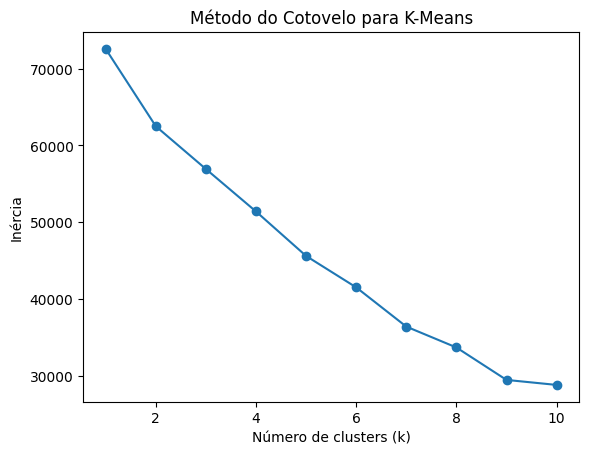

In [20]:
inertia = []
K = range(1, 11)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42, n_init='auto')
    modelo.fit(X_scaled_cluster)
    inertia.append(modelo.inertia_)

plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo para K-Means")
plt.show()

### 3.2. Execução da Clusterização K-Means

Com base no método do cotovelo, um número de clusters é escolhido e o K-Means é aplicado aos dados padronizados. O cluster resultante é adicionado ao DataFrame `df_top10`.

In [21]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled_cluster)
df_top10['cluster'] = clusters

### 3.3. Análise da Composição dos Clusters

A distribuição dos gêneros dentro de cada cluster é visualizada para compreender as características de cada grupo de filmes.

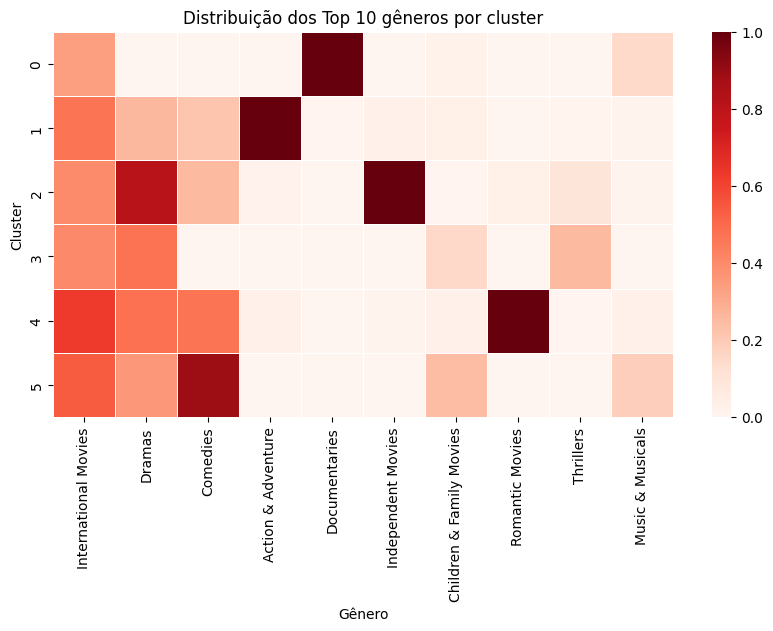

In [22]:
cluster_generos_mean = df_top10.groupby('cluster')[top_generos].mean()

plt.figure(figsize=(10,5))
sns.heatmap(
    cluster_generos_mean,
    cmap="Reds",
    linewidths=0.5
)
plt.title("Distribuição dos Top 10 gêneros por cluster")
plt.xlabel("Gênero")
plt.ylabel("Cluster")
plt.show()

In [23]:
for c in cluster_generos_mean.index:
    print(f"\nCluster {c}")
    print(cluster_generos_mean.loc[c].sort_values(ascending=False).head(5))


Cluster 0
Documentaries               1.000000
International Movies        0.338078
Music & Musicals            0.148280
Children & Family Movies    0.020166
Dramas                      0.003559
Name: 0, dtype: float64

Cluster 1
Action & Adventure          0.998779
International Movies        0.467643
Dramas                      0.261294
Comedies                    0.216117
Children & Family Movies    0.031746
Name: 1, dtype: float64

Cluster 2
Independent Movies      1.000000
Dramas                  0.813559
International Movies    0.398305
Comedies                0.250000
Thrillers               0.096045
Name: 2, dtype: float64

Cluster 3
Dramas                      0.470407
International Movies        0.399897
Thrillers                   0.252187
Children & Family Movies    0.152342
Comedies                    0.002059
Name: 3, dtype: float64

Cluster 4
Romantic Movies             1.000000
International Movies        0.627551
Dramas                      0.479592
Comedies          

### 3.4. Visualização dos Clusters com Análise de Componentes Principais (PCA)

Para facilitar a visualização de dados multidimensionais, a Análise de Componentes Principais (PCA) é aplicada para reduzir as features a duas dimensões (PC1 e PC2) e plotar os clusters em um gráfico de dispersão.

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_cluster)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

df_pca["cluster"] = df_top10["cluster"].values
df_pca["titulo"] = df_top10["titulo"].values

In [25]:
fig = px.scatter(
    df_pca,
    x="PC1",
    y="PC2",
    color="cluster",
    hover_data=["titulo"],
    title="Clusterização de filmes (PCA)"
)
fig.show()

## 4. Sistema de Recomendação de Filmes Baseado em Similaridade (KNN)

Esta é a seção central do projeto, onde um sistema de recomendação é construído e demonstrado utilizando o algoritmo K-Nearest Neighbors (KNN). Ele recomenda filmes com base na duração, classificação indicativa e gêneros.

### 4.1. Preparação das Features para o Modelo KNN

As features que o modelo KNN irá considerar (duração, classificação numérica e os 10 gêneros principais) são definidas, e a padronização é aplicada.

In [26]:
# As features são as características que o knn vai olhar para calcular a distância
features = ["duracao_em_min", "classificacao_num"] + list(top_generos)
X_knn = df_top10[features]

# Escalar para não ter nenhum número discrepante
scaler_knn = StandardScaler()
X_scaled_knn = scaler_knn.fit_transform(X_knn)

### 4.2. Construção do Modelo K-Nearest Neighbors (KNN)

O modelo KNN é inicializado e treinado para encontrar os filmes mais próximos no espaço de features.

In [27]:
knn = NearestNeighbors(
    n_neighbors=6,  # 5 recomendações + o filme escolhido
    metric="euclidean"
)
knn.fit(X_scaled_knn)

NearestNeighbors(metric='euclidean', n_neighbors=6)

### 4.3. Função para Recomendar Filmes

Uma função é criada que, dado o índice de um filme, retorna uma lista de filmes recomendados com base na sua similaridade.

In [39]:
def recomendar_filmes(idx):

    # mostrar informações do filme escolhido
    filme_escolhido = df_top10.iloc[idx]

    print(f"🎬 Filme Escolhido: {filme_escolhido['titulo']} ")
    print(f"Cluster: {filme_escolhido['cluster']} | Classificação: {filme_escolhido['classificacao_br']} | Gênero: {filme_escolhido['genero']} | Duração: {filme_escolhido['duracao_em_min']} min")
    print("\nFilmes recomendados:\n")

    # encontrar vizinhos
    distances, indices = knn.kneighbors(X_scaled_knn[idx].reshape(1, -1))

    # Criar um DataFrame temporário com todos os vizinhos e suas distâncias
    temp_recs = df_top10.iloc[indices[0]].copy()
    temp_recs["distancia"] = distances[0]

    # Filtrar o filme escolhido e quaisquer outros filmes com distância 0 (duplicatas exatas)
    recomendacoes = temp_recs[temp_recs["distancia"] > 0].copy()

    # Ordenar por distância (os mais próximos primeiro)
    recomendacoes = recomendacoes.sort_values("distancia", ascending=True)

    return recomendacoes[["titulo", "cluster", "classificacao_br", "genero", "duracao_em_min","distancia"]]

### 4.4. Teste e Visualização da Recomendação

Finalmente, a função de recomendação é testada com um filme específico, e o filme escolhido e suas recomendações são visualizados no gráfico PCA, destacando a similaridade dentro dos clusters. **Este é o ponto crucial da análise!**

In [42]:
# Testar recomendação - O índice vai de 0 a 6047 (número de filmes em df_top10)
# Para este exemplo, escolhemos o filme no índice 30.
recomendar_filmes(30)

🎬 Filme Escolhido: Naruto Shippuden the Movie: Blood Prison 
Cluster: 1 | Classificação: 14 | Gênero: Action & Adventure, Anime Features, International Movies | Duração: 102.0 min

Filmes recomendados:



,titulo,cluster,classificacao_br,genero,duracao_em_min,distancia
7284,Legendary Weapons of China,1,14,"Action & Adventure, Cult Movies, International...",101.0,0.035228
4769,GODZILLA City on the Edge of Battle,1,14,"Action & Adventure, Anime Features, Internatio...",101.0,0.035228
4243,The Seven Deadly Sins the Movie: Prisoners of ...,1,14,"Action & Adventure, Anime Features, Internatio...",100.0,0.070455
1334,Monster Run,1,14,"Action & Adventure, International Movies",104.0,0.070455


In [41]:
filme_index = 30
distances, indices = knn.kneighbors(X_scaled_knn[filme_index].reshape(1, -1))

# Filtrar o filme escolhido da lista de recomendações para garantir que ele seja marcado apenas como 'Filme escolhido'
indices_recomendados = [idx for idx in indices[0] if idx != filme_index]

# Criar uma cópia do df_pca para a visualização das recomendações
df_pca_rec = df_pca.copy()

# Adicionar tipos para os filmes no gráfico
df_pca_rec["tipo"] = "Outros"
df_pca_rec.loc[filme_index, "tipo"] = "Filme escolhido"
df_pca_rec.loc[indices_recomendados, "tipo"] = "Recomendado"

# Ajustes para o tamanho e opacidade no gráfico
df_pca_rec["tamanho"] = 4
df_pca_rec.loc[indices_recomendados, "tamanho"] = 8
df_pca_rec.loc[filme_index, "tamanho"] = 28
df_pca_rec["opacidade"] = 0.2
df_pca_rec.loc[indices_recomendados, "opacidade"] = 0.9
df_pca_rec.loc[filme_index, "opacidade"] = 1

# Criar o gráfico interativo
fig = px.scatter(
    df_pca_rec,
    x="PC1",
    y="PC2",
    color="tipo",
    symbol="cluster",
    size="tamanho",
    opacity=0.8,
    color_discrete_map={
        "Outros": "lightgray",
        "Recomendado": "orange",
        "Filme escolhido": "red"
    },
    hover_data=["titulo", "cluster", "tipo"], # Adiciona 'tipo' para facilitar a depuração
    title="Sistema de Recomendação Baseado em Similaridade (Visualização PCA)",
    width=1200,
    height=600
)
fig.show()